# Laboratorio Semana 4: Seq2Seq Ingles-Espanol desde cero

**Curso:** Deep Learning  
**Valor:** 4% de la nota del curso  
**Entrega:** Notebook ejecutado (.ipynb) con todas las celdas con salida visible

---

## Contexto

Esta semana implementa un modelo Seq2Seq completo para traduccion ingles-espanol con traducciones **naturales en espanol**: el corpus tiene deliberadamente oraciones donde el espanol es mas corto (por elision del sujeto: *she sings well* -> *canta bien*), mas largo (por perifrasis verbales: *the cat sleeps* -> *el gato esta durmiendo*), o del mismo largo. Esa asimetria de largo es exactamente la razon de ser de la arquitectura Encoder-Decoder.

Pipeline:
```
oracion_EN -> [E_enc] -> [Encoder LSTM] -> c = h_T^enc
                                            |
<SOS>+oracion_ES -> [E_dec] -> [Decoder LSTM] -> [W_out+softmax] -> prediccion
```

## Reglas

- Use unicamente PyTorch. No use `nn.LSTM`, `nn.Embedding`, `nn.Linear` ni capas de alto nivel.
- El backward debe ser **manual**. No use `loss.backward()`.
- No modifique los pesos iniciales ni el corpus.
- La celda final calcula su nota automatica sobre los **60 puntos** de codigo.

In [1]:
import torch
import torch.nn.functional as F
import hashlib, numpy as np, random, time
from collections import Counter
import matplotlib.pyplot as plt

def _hash_tensor(t, decimals=5):
    arr = np.round(t.detach().numpy().astype(np.float64), decimals)
    return hashlib.sha256(arr.tobytes()).hexdigest()

_resultados = {}
print(f'PyTorch: {torch.__version__}')

PyTorch: 2.13.0+cpu


---
## Bloque 0: Corpus, vocabularios y pesos iniciales (dado, no modificar)

In [2]:
CORPUS_COMPLETO = [
    ("i love you", "te amo"),
    ("i drink water", "bebo agua"),
    ("i read the news", "leo las noticias"),
    ("i write a book", "escribo un libro"),
    ("i hear music", "escucho musica"),
    ("i call my mother", "llamo a mi madre"),
    ("i take a photo", "tomo una foto"),
    ("i finish my work", "termino mi trabajo"),
    ("i open the book", "abro el libro"),
    ("i run every morning", "corro cada manana"),
    ("i learn spanish", "aprendo espanol"),
    ("i like coffee", "me gusta el cafe"),
    ("i work every day", "trabajo todos los dias"),
    ("i buy fresh bread", "compro pan fresco"),
    ("she reads books", "lee libros"),
    ("she sings well", "canta bien"),
    ("she cooks dinner", "cocina la cena"),
    ("she opens the door", "abre la puerta"),
    ("she sleeps early", "duerme temprano"),
    ("she buys flowers", "compra flores"),
    ("she draws pictures", "dibuja imagenes"),
    ("she visits her friend", "visita a su amiga"),
    ("she teaches math", "ensena matematica"),
    ("she paints a picture", "pinta un cuadro"),
    ("she writes a poem", "escribe un poema"),
    ("she enjoys the music", "disfruta la musica"),
    ("she prepares the meal", "prepara la comida"),
    ("he runs fast", "corre rapido"),
    ("he writes a letter", "escribe una carta"),
    ("he closes the window", "cierra la ventana"),
    ("he eats an apple", "come una manzana"),
    ("he drives a car", "conduce un carro"),
    ("he fixes the bike", "arregla la bicicleta"),
    ("he plays the guitar", "toca la guitarra"),
    ("he studies history", "estudia historia"),
    ("he answers the phone", "contesta el telefono"),
    ("he repairs the chair", "repara la silla"),
    ("he teaches the class", "ensena la clase"),
    ("we eat bread", "comemos pan"),
    ("we walk together", "caminamos juntos"),
    ("we leave early", "salimos temprano"),
    ("we cook together", "cocinamos juntos"),
    ("we swim in the sea", "nadamos en el mar"),
    ("we watch the stars", "miramos las estrellas"),
    ("we visit the museum", "visitamos el museo"),
    ("we celebrate together", "celebramos juntos"),
    ("we enjoy the summer", "disfrutamos el verano"),
    ("they play soccer", "juegan futbol"),
    ("they arrive late", "llegan tarde"),
    ("they build a house", "construyen una casa"),
    ("they clean the room", "limpian el cuarto"),
    ("they watch the movie", "ven la pelicula"),
    ("they travel by train", "viajan en tren"),
    ("they eat together", "comen juntos"),
    ("they sing a song", "cantan una cancion"),
    ("they dance all night", "bailan toda la noche"),
    ("they plant the seeds", "plantan las semillas"),
    ("they clean the street", "limpian la calle"),
    ("the cat sleeps", "el gato esta durmiendo"),
    ("the dog barks", "el perro esta ladrando"),
    ("the bird flies", "el pajaro esta volando"),
    ("the sun shines", "el sol esta brillando"),
    ("the fish swims", "el pez esta nadando"),
    ("the baby laughs", "el bebe esta riendo"),
    ("the teacher explains", "el profesor esta explicando"),
    ("the rain falls", "la lluvia esta cayendo"),
    ("the moon rises", "la luna esta subiendo"),
    ("the wind blows", "el viento esta soplando"),
    ("the fire burns", "el fuego esta ardiendo"),
    ("the clock ticks", "el reloj esta sonando"),
    ("we study english", "estudiamos ingles"),
    ("we paint the wall", "pintamos la pared"),
    ("we drink hot tea", "bebemos te caliente"),
    ("we meet every week", "nos reunimos cada semana"),
    ("the cat drinks milk", "el gato bebe leche"),
    ("the child plays", "el nino juega"),
    ("he reads the newspaper", "lee el periodico"),
    ("she closes her eyes", "cierra los ojos"),
]

# Split 75/25 reproducible
random.seed(42)
indices = list(range(len(CORPUS_COMPLETO)))
random.shuffle(indices)
n_train = int(len(CORPUS_COMPLETO) * 0.75)
TRAIN_DATA = [CORPUS_COMPLETO[i] for i in indices[:n_train]]
TEST_DATA  = [CORPUS_COMPLETO[i] for i in indices[n_train:]]
print(f'Train: {len(TRAIN_DATA)} pares, Test: {len(TEST_DATA)} pares')
print(f'Primer par de entrenamiento: {TRAIN_DATA[0]}')
# Verificar distribucion de largos
diffs = [len(tgt.split())-len(src.split()) for src,tgt in CORPUS_COMPLETO]
from collections import Counter
print('Diferencia largo ES - largo EN:', dict(sorted(Counter(diffs).items())))


Train: 58 pares, Test: 20 pares
Primer par de entrenamiento: ('they play soccer', 'juegan futbol')
Diferencia largo ES - largo EN: {-1: 57, 0: 8, 1: 13}


In [3]:
SOS, EOS, PAD, UNK = '<SOS>', '<EOS>', '<PAD>', '<UNK>'
SPECIAL = [PAD, UNK, SOS, EOS]

def build_vocab(sentences):
    words = set()
    for s in sentences: words.update(s.lower().split())
    vocab = SPECIAL + sorted(words)
    w2i = {w: i for i, w in enumerate(vocab)}
    i2w = {i: w for w, i in w2i.items()}
    return vocab, w2i, i2w

src_vocab, src_w2i, src_i2w = build_vocab([p[0] for p in CORPUS_COMPLETO])
tgt_vocab, tgt_w2i, tgt_i2w = build_vocab([p[1] for p in CORPUS_COMPLETO])
src_V = len(src_vocab); tgt_V = len(tgt_vocab)
print(f'Vocabulario EN: {src_V} palabras')
print(f'Vocabulario ES: {tgt_V} palabras')

def tokenize_src(sentence):
    return [src_w2i.get(w.lower(), src_w2i[UNK]) for w in sentence.split()]

def tokenize_tgt(sentence):
    return ([tgt_w2i[SOS]] +
            [tgt_w2i.get(w.lower(), tgt_w2i[UNK]) for w in sentence.split()] +
            [tgt_w2i[EOS]])

Vocabulario EN: 158 palabras
Vocabulario ES: 163 palabras


In [4]:
d_emb = 16; d_hid = 32
torch.manual_seed(42)
E_enc = torch.randn(d_emb, src_V) * 0.1
E_dec = torch.randn(d_emb, tgt_V) * 0.1
Wf_enc=torch.randn(d_hid,d_hid+d_emb)*0.1; bf_enc=torch.zeros(d_hid)
Wi_enc=torch.randn(d_hid,d_hid+d_emb)*0.1; bi_enc=torch.zeros(d_hid)
Wc_enc=torch.randn(d_hid,d_hid+d_emb)*0.1; bc_enc=torch.zeros(d_hid)
Wo_enc=torch.randn(d_hid,d_hid+d_emb)*0.1; bo_enc=torch.zeros(d_hid)
Wf_dec=torch.randn(d_hid,d_hid+d_emb)*0.1; bf_dec=torch.zeros(d_hid)
Wi_dec=torch.randn(d_hid,d_hid+d_emb)*0.1; bi_dec=torch.zeros(d_hid)
Wc_dec=torch.randn(d_hid,d_hid+d_emb)*0.1; bc_dec=torch.zeros(d_hid)
Wo_dec=torch.randn(d_hid,d_hid+d_emb)*0.1; bo_dec=torch.zeros(d_hid)
W_out = torch.randn(tgt_V, d_hid) * 0.1; b_out = torch.zeros(tgt_V)
alpha = 0.01
print(f'E_enc: {E_enc.shape}, Wf_enc: {Wf_enc.shape}, W_out: {W_out.shape}')

E_enc: torch.Size([16, 158]), Wf_enc: torch.Size([32, 48]), W_out: torch.Size([163, 32])


---
## Bloque 1: Lookup de embeddings

Implemente `get_embedding` que selecciona la columna `idx` de la matriz `E`:

$$\mathbf{e} = E[:, \text{idx}]$$

El backward de esta operacion acumula gradiente **solo** en la columna `idx`: las palabras que no aparecen en la secuencia no reciben actualizacion.

Implemente tambien `get_embedding_batch` para una lista de indices.

In [ ]:
def get_embedding(E, idx):
    """
    Selecciona la columna idx de E. Retorna tensor (d_emb,).
    """
    # SU CODIGO AQUI
    # Extraer solo la columna del token para actualizar solo esa en el backward
    return E[:, idx]

def get_embedding_batch(E, indices):
    """Retorna lista de embeddings para una lista de indices."""
    # SU CODIGO AQUI
    # Obtener los embeddings para toda la lista de índices
    return [get_embedding(E, idx) for idx in indices]

emb_test = get_embedding(E_enc, 0)
print(f'Embedding token 0: {emb_test.shape if emb_test is not None else None}')

Embedding token 0: torch.Size([16])


---
## Bloque 2: Celda LSTM y forward del encoder

Implemente `lstm_cell` con las cinco ecuaciones del LSTM.  
Luego implemente `encoder_forward` que lee la secuencia de entrada completa y retorna:
- `context_h`: hidden state final $h_T^{enc}$ (vector de contexto)
- `context_c`: cell state final $c_T^{enc}$
- `enc_caches`: lista de caches de cada paso (necesarios para el backward)

Guarde el indice del embedding en cada cache con la clave `'emb_idx'`.

**Importante:** el par de verificacion es `TRAIN_DATA[0] = ('they play soccer', 'juegan futbol')`. El encoder lee 3 tokens en ingles y el decoder genera 2 tokens en espanol mas EOS. Esta asimetria es intencional y debe funcionar sin cambios en el codigo.

In [ ]:
def lstm_cell(h, c, x, Wf, bf, Wi, bi, Wc, bc, Wo, bo):
    """
    Un paso de tiempo LSTM.
    Retorna (h_new, c_new, cache).
    El cache debe contener: concat, h_prev, c_prev, f, i, ct, c_t, o, h_t
    """
    # SU CODIGO AQUI
    # Calcular las 3 compuertas (forget, input, output) y el cell candidate
    concat = torch.cat([h, x])                  # (d_hid + d_emb,)
    f  = torch.sigmoid(Wf @ concat + bf)        # puerta de olvido
    i  = torch.sigmoid(Wi @ concat + bi)        # puerta de entrada
    ct = torch.tanh(Wc @ concat + bc)           # candidato de celda
    c_t = f * c + i * ct                        # nuevo cell state
    o  = torch.sigmoid(Wo @ concat + bo)        # puerta de salida
    h_t = o * torch.tanh(c_t)                   # nuevo hidden state
    cache = {'concat': concat, 'h_prev': h, 'c_prev': c,
             'f': f, 'i': i, 'ct': ct, 'c_t': c_t, 'o': o, 'h_t': h_t}
    return h_t, c_t, cache

def encoder_forward(src_indices, E_enc, Wf_enc, bf_enc, Wi_enc, bi_enc,
                    Wc_enc, bc_enc, Wo_enc, bo_enc):
    """
    Forward del encoder. Retorna (context_h, context_c, enc_caches).
    """
    h = torch.zeros(d_hid); c = torch.zeros(d_hid); caches = []
    # SU CODIGO AQUI
    # Leer secuencia de entrada token por token
    for idx in src_indices:
        x = get_embedding(E_enc, idx)
        h, c, cache = lstm_cell(h, c, x, Wf_enc, bf_enc, Wi_enc, bi_enc,
                                Wc_enc, bc_enc, Wo_enc, bo_enc)
        cache['emb_idx'] = idx      # para acumular dE_enc[:, idx] en el backward
        caches.append(cache)
    return h, c, caches

# Verificar con TRAIN_DATA[0]: 'they play soccer' -> 'juegan futbol'
src_test = tokenize_src(TRAIN_DATA[0][0])
context_h, context_c, enc_caches = encoder_forward(
    src_test, E_enc, Wf_enc, bf_enc, Wi_enc, bi_enc, Wc_enc, bc_enc, Wo_enc, bo_enc)
print(f'Entrada EN: {TRAIN_DATA[0][0]} -> tokens: {src_test}')
print(f'context_h forma: {context_h.shape if context_h is not None else None}')
print(f'Caches encoder: {len(enc_caches)} (uno por token de entrada)')

Entrada EN: they play soccer -> tokens: [138, 103, 122]
context_h forma: torch.Size([32])
Caches encoder: 3 (uno por token de entrada)


In [7]:
# VERIFICACION BLOQUE 2
_H = 'a1c22d089ecfb52bdae47e330603a46d492f9318dc6b2071956ef1a9c406eeec'
try:
    assert context_h is not None and context_h.shape == (d_hid,), \
        f'context_h debe ser ({d_hid},), obtenida {getattr(context_h,"shape",None)}'
    assert len(enc_caches) == len(src_test), \
        f'enc_caches debe tener {len(src_test)} entradas, tiene {len(enc_caches)}'
    assert _hash_tensor(context_h) == _H, 'context_h incorrecto.'
    _resultados['b2'] = True; print('BLOQUE 2: CORRECTO')
except AssertionError as e:
    _resultados['b2'] = False; print(f'BLOQUE 2: INCORRECTO\n  {e}')

BLOQUE 2: CORRECTO


---
## Bloque 3: Forward del decoder con teacher forcing

Implemente `decoder_forward` con teacher forcing.

El par de verificacion tiene **largo asimetrico**: el encoder leyo 3 tokens (*they play soccer*) y el decoder debe generar 2 tokens en espanol (*juegan futbol*) mas EOS. Su implementacion debe manejar cualquier combinacion de largos sin codigo especial.

- Input del decoder: `[SOS, juegan]` (largo 2)
- Target del decoder: `[juegan, futbol, EOS]` (largo 3)
- El decoder corre exactamente `len(dec_input_indices)` pasos

In [ ]:
def decoder_forward(dec_input_indices, dec_target_indices, context_h, context_c,
                    E_dec, Wf_dec, bf_dec, Wi_dec, bi_dec,
                    Wc_dec, bc_dec, Wo_dec, bo_dec, W_out, b_out):
    """
    Forward decoder con teacher forcing.
    Retorna (logits_list, dec_caches)
    logits_list: lista de tensores (tgt_V,), uno por paso
    """
    h = context_h.clone(); c = context_c.clone()
    caches = []; logits_list = []
    # SU CODIGO AQUI
    for idx in dec_input_indices:
        # Teacher forcing: forzar el token real como entrada
        x = get_embedding(E_dec, idx)
        h, c, cache = lstm_cell(h, c, x, Wf_dec, bf_dec, Wi_dec, bi_dec,
                                Wc_dec, bc_dec, Wo_dec, bo_dec)
        cache['emb_idx'] = idx
        caches.append(cache)
        # Guardar predicciones
        logits_list.append(W_out @ h + b_out)      # (tgt_V,)
    return logits_list, caches

tgt_tokens_full = tokenize_tgt(TRAIN_DATA[0][1])
dec_input_idx  = tgt_tokens_full[:-1]   # [SOS, juegan]
dec_target_idx = tgt_tokens_full[1:]    # [juegan, futbol, EOS]
print(f'Salida ES: {TRAIN_DATA[0][1]} -> tokens: {tgt_tokens_full}')
print(f'Input decoder:  {dec_input_idx}  (largo {len(dec_input_idx)})')
print(f'Target decoder: {dec_target_idx} (largo {len(dec_target_idx)})')
print(f'Largo EN ({len(src_test)}) != Largo ES ({len(dec_target_idx)}): asimetria correcta')
logits_list, dec_caches = decoder_forward(
    dec_input_idx, dec_target_idx, context_h, context_c,
    E_dec, Wf_dec, bf_dec, Wi_dec, bi_dec, Wc_dec, bc_dec, Wo_dec, bo_dec, W_out, b_out)
print(f'Pasos del decoder: {len(logits_list)}')
print(f'Forma de cada logit: {logits_list[0].shape if logits_list else None}')

Salida ES: juegan futbol -> tokens: [2, 81, 73, 3]
Input decoder:  [2, 81, 73]  (largo 3)
Target decoder: [81, 73, 3] (largo 3)
Largo EN (3) != Largo ES (3): asimetria correcta
Pasos del decoder: 3
Forma de cada logit: torch.Size([163])


---
## Bloque 4: Perdida de entropia cruzada categorica

$$L = \frac{1}{S} \sum_{s=1}^{S} \left(-\log \hat{y}_s[w_s^*]\right)$$

Use `F.log_softmax` para estabilidad numerica. Resultado: tensor escalar.

In [ ]:
def compute_loss(logits_list, target_indices):
    """
    Entropia cruzada categorica promedio sobre la secuencia.
    Retorna tensor escalar.
    """
    # SU CODIGO AQUI
    total = 0.0
    for z, w_star in zip(logits_list, target_indices):
        # Usar log_softmax para evitar inestabilidad numérica
        total = total + (-F.log_softmax(z, dim=0)[w_star])
    return total / len(target_indices)

S = len(dec_target_idx)
loss_mean = compute_loss(logits_list, dec_target_idx)
print(f'S (largo secuencia decodificada): {S}')
print(f'loss_mean: {loss_mean.item() if loss_mean is not None else None:.4f}')

S (largo secuencia decodificada): 3
loss_mean: 5.0933


In [10]:
# VERIFICACION BLOQUE 4
try:
    assert loss_mean is not None, 'loss_mean no definido.'
    assert abs(loss_mean.item() - 5.093276) < 1e-3, \
        f'loss_mean incorrecto: {loss_mean.item():.6f}, esperado ~5.093'
    _resultados['b4'] = True; print('BLOQUE 4: CORRECTO')
except AssertionError as e:
    _resultados['b4'] = False; print(f'BLOQUE 4: INCORRECTO\n  {e}')

BLOQUE 4: CORRECTO


---
## BACKWARD PASS

---

## Bloque 5: Backward del decoder

BPTT sobre los $S$ pasos del decoder en orden inverso.

En cada paso $s$:
1. $\frac{\partial L}{\partial z_s} = \frac{1}{S}\left(\hat{y}_s - \mathbf{1}_{w_s^*}\right)$
2. Acumular en `dW_out`, `db_out`
3. Gradiente hacia $h_s^{dec}$: suma de `W_out.T @ dL_dz` y el gradiente del paso siguiente
4. BPTT de la celda LSTM
5. Acumular en pesos del decoder y en `dE_dec[:, emb_idx]`
6. Propagar `dL_dh_next` y `dL_dc_next`

Al salir del loop: `dL_dh_context = dL_dh_dec_next` inicia el backward del encoder.

In [11]:
def lstm_backward(cache, dL_dh, dL_dc_next, Wf, Wi, Wc, Wo):
    """
    BPTT de un paso de la celda LSTM (usado por encoder y decoder).
    dL_dh: gradiente total que llega a h_t (salida + paso siguiente)
    dL_dc_next: gradiente que llega a c_t desde el paso siguiente
    Retorna ((dWf, dbf, dWi, dbi, dWc, dbc, dWo, dbo), dx, dh_prev, dc_prev)
    """
    concat = cache['concat']; c_prev = cache['c_prev']
    f = cache['f']; i = cache['i']; ct = cache['ct']; c_t = cache['c_t']; o = cache['o']
    tanh_c = torch.tanh(c_t)

    # h_t = o * tanh(c_t)
    dz_o  = (dL_dh * tanh_c) * o * (1 - o)                    # pre-activacion puerta salida
    dc    = dL_dc_next + dL_dh * o * (1 - tanh_c ** 2)        # gradiente total sobre c_t
    # c_t = f * c_prev + i * ct
    dz_f  = (dc * c_prev) * f * (1 - f)
    dz_i  = (dc * ct) * i * (1 - i)
    dz_ct = (dc * i) * (1 - ct ** 2)

    # dW = outer(dz, concat) porque z = W @ concat + b
    dWf = torch.outer(dz_f, concat);  dWi = torch.outer(dz_i, concat)
    dWc = torch.outer(dz_ct, concat); dWo = torch.outer(dz_o, concat)

    # concat = [h_prev, x] -> el gradiente se reparte entre las dos mitades
    dconcat = Wf.T @ dz_f + Wi.T @ dz_i + Wc.T @ dz_ct + Wo.T @ dz_o
    dh_prev = dconcat[:d_hid]
    dx      = dconcat[d_hid:]
    dc_prev = dc * f
    return (dWf, dz_f, dWi, dz_i, dWc, dz_ct, dWo, dz_o), dx, dh_prev, dc_prev

dWf_dec=torch.zeros_like(Wf_dec); dbf_dec=torch.zeros_like(bf_dec)
dWi_dec=torch.zeros_like(Wi_dec); dbi_dec=torch.zeros_like(bi_dec)
dWc_dec=torch.zeros_like(Wc_dec); dbc_dec=torch.zeros_like(bc_dec)
dWo_dec=torch.zeros_like(Wo_dec); dbo_dec=torch.zeros_like(bo_dec)
dW_out =torch.zeros_like(W_out);  db_out =torch.zeros_like(b_out)
dE_dec =torch.zeros_like(E_dec)
dL_dh_dec_next = torch.zeros(d_hid)
dL_dc_dec_next = torch.zeros(d_hid)

for s in reversed(range(S)):
    cc = dec_caches[s]
    z  = logits_list[s]
    tgt_idx = dec_target_idx[s]
    # SU CODIGO AQUI
    # 1) dL/dz = (y_hat - onehot) / S
    y_hat = F.softmax(z, dim=0)
    dL_dz = y_hat.clone(); dL_dz[tgt_idx] -= 1.0; dL_dz = dL_dz / S

    # 2) capa de salida: z = W_out @ h_s + b_out
    dW_out += torch.outer(dL_dz, cc['h_t'])
    db_out += dL_dz

    # 3) gradiente hacia h_s: por la salida + por el paso siguiente del decoder
    dL_dh = W_out.T @ dL_dz + dL_dh_dec_next

    # 4) BPTT de la celda LSTM del decoder
    (gWf, gbf, gWi, gbi, gWc, gbc, gWo, gbo), dx, dh_prev, dc_prev = lstm_backward(
        cc, dL_dh, dL_dc_dec_next, Wf_dec, Wi_dec, Wc_dec, Wo_dec)

    # 5) acumular en los pesos del decoder y en la columna del embedding usado
    dWf_dec += gWf; dbf_dec += gbf
    dWi_dec += gWi; dbi_dec += gbi
    dWc_dec += gWc; dbc_dec += gbc
    dWo_dec += gWo; dbo_dec += gbo
    dE_dec[:, cc['emb_idx']] += dx

    # 6) propagar hacia el paso anterior
    dL_dh_dec_next = dh_prev
    dL_dc_dec_next = dc_prev

dL_dh_context = dL_dh_dec_next.clone()
dL_dc_context = dL_dc_dec_next.clone()
print(f'dWf_dec forma: {dWf_dec.shape}')
print(f'dL_dh_context forma: {dL_dh_context.shape}')

dWf_dec forma: torch.Size([32, 48])
dL_dh_context forma: torch.Size([32])


In [12]:
# VERIFICACION BLOQUE 5
_H = '91fcfa6f4bce42112eeec9128a60f328dcf657eb74249caafef27b17fc772547'
try:
    assert _hash_tensor(dWf_dec) == _H, 'dWf_dec incorrecto.'
    _resultados['b5'] = True; print('BLOQUE 5: CORRECTO')
except AssertionError as e:
    _resultados['b5'] = False; print(f'BLOQUE 5: INCORRECTO\n  {e}')

BLOQUE 5: CORRECTO


---
## Bloque 6: Backward del encoder

`dL_dh_context` entra al encoder como gradiente de $h_T^{enc}$.  
Aplique BPTT sobre los $T$ pasos del encoder en orden inverso,  
acumulando gradientes en los pesos del encoder y en `dE_enc[:, emb_idx]`.

In [13]:
dWf_enc=torch.zeros_like(Wf_enc); dbf_enc=torch.zeros_like(bf_enc)
dWi_enc=torch.zeros_like(Wi_enc); dbi_enc=torch.zeros_like(bi_enc)
dWc_enc=torch.zeros_like(Wc_enc); dbc_enc=torch.zeros_like(bc_enc)
dWo_enc=torch.zeros_like(Wo_enc); dbo_enc=torch.zeros_like(bo_enc)
dE_enc =torch.zeros_like(E_enc)
dL_dh_enc_next = dL_dh_context.clone()
dL_dc_enc_next = dL_dc_context.clone()

for t in reversed(range(len(enc_caches))):
    cc = enc_caches[t]
    # SU CODIGO AQUI
    # el encoder no produce logits: todo el gradiente entra por dL_dh_enc_next
    (gWf, gbf, gWi, gbi, gWc, gbc, gWo, gbo), dx, dh_prev, dc_prev = lstm_backward(
        cc, dL_dh_enc_next, dL_dc_enc_next, Wf_enc, Wi_enc, Wc_enc, Wo_enc)
    dWf_enc += gWf; dbf_enc += gbf
    dWi_enc += gWi; dbi_enc += gbi
    dWc_enc += gWc; dbc_enc += gbc
    dWo_enc += gWo; dbo_enc += gbo
    dE_enc[:, cc['emb_idx']] += dx      # solo la columna del token leido en t
    dL_dh_enc_next = dh_prev
    dL_dc_enc_next = dc_prev

print(f'dWf_enc forma: {dWf_enc.shape}')
print(f'dE_enc forma:  {dE_enc.shape}')

dWf_enc forma: torch.Size([32, 48])
dE_enc forma:  torch.Size([16, 158])


In [14]:
# VERIFICACION BLOQUE 6
_HASHES_B6 = {
    'dWf_enc': '3fafa04007ed020a0ccd8969f95aa4ba130aafd7aa4b60a7efbbcbc73593f2c5',
    'dE_enc':  '56bb53461e329a75e94c28b9cc4599d9461b9302793853a5d698b8905f6df7d5',
}
try:
    assert _hash_tensor(dWf_enc) == _HASHES_B6['dWf_enc'], 'dWf_enc incorrecto.'
    assert _hash_tensor(dE_enc)  == _HASHES_B6['dE_enc'],  'dE_enc incorrecto.'
    _resultados['b6'] = True; print('BLOQUE 6: CORRECTO')
except AssertionError as e:
    _resultados['b6'] = False; print(f'BLOQUE 6: INCORRECTO\n  {e}')

BLOQUE 6: CORRECTO


---
## Bloque 7: Gradientes de embeddings - version completa vs diccionario

Ya tiene `dE_enc` completa (misma forma que `E_enc`, ceros en columnas no usadas).  
Implemente la version eficiente con diccionario: guarda solo los gradientes de las columnas que aparecieron en la secuencia.  
Mida el tiempo de actualizacion con ambas versiones sobre 1000 repeticiones y compare.

In [15]:
def compute_dE_dict(enc_caches, dL_dh_context, dL_dc_context,
                    Wf_enc, Wi_enc, Wc_enc, Wo_enc):
    """
    Gradiente de embeddings del encoder usando diccionario.
    Retorna dict {idx: grad_tensor (d_emb,)}
    """
    dE_dict = {}
    dh_next = dL_dh_context.clone()
    dc_next = dL_dc_context.clone()
    for t in reversed(range(len(enc_caches))):
        cc = enc_caches[t]
        # SU CODIGO AQUI
        # BPTT identico al Bloque 6 pero acumular en dE_dict en lugar de dE_enc
        _, dx, dh_prev, dc_prev = lstm_backward(cc, dh_next, dc_next,
                                                Wf_enc, Wi_enc, Wc_enc, Wo_enc)
        idx = cc['emb_idx']
        # un token repetido en la oracion debe sumar sus contribuciones
        dE_dict[idx] = dE_dict[idx] + dx if idx in dE_dict else dx.clone()
        dh_next = dh_prev
        dc_next = dc_prev
    return dE_dict

N_rep = 1000
t0 = time.time()
for _ in range(N_rep): _ = E_enc - alpha * dE_enc
t_full = (time.time()-t0)/N_rep*1e6

dE_dict = compute_dE_dict(enc_caches, dL_dh_context, dL_dc_context,
                           Wf_enc, Wi_enc, Wc_enc, Wo_enc)
t0 = time.time()
for _ in range(N_rep):
    E_tmp = E_enc.clone()
    for idx, grad in (dE_dict or {}).items(): E_tmp[:, idx] -= alpha * grad
t_dict = (time.time()-t0)/N_rep*1e6

print(f'Actualizacion completa:    {t_full:.2f} us')
print(f'Actualizacion diccionario: {t_dict:.2f} us')
print(f'Tokens con gradiente: {len(dE_dict) if dE_dict else 0} de {src_V}')

Actualizacion completa:    20.79 us
Actualizacion diccionario: 129.44 us
Tokens con gradiente: 3 de 158


In [16]:
# VERIFICACION BLOQUE 7
try:
    assert dE_dict is not None and len(dE_dict) > 0, 'dE_dict vacio.'
    dE_from_dict = torch.zeros_like(E_enc)
    for idx, grad in dE_dict.items(): dE_from_dict[:, idx] += grad
    assert torch.allclose(dE_enc, dE_from_dict, atol=1e-5), \
        'Version diccionario produce valores distintos a la version completa.'
    _resultados['b7'] = True; print('BLOQUE 7: CORRECTO')
    print(f'  Ambas versiones coinciden. {len(dE_dict)} de {src_V} tokens tienen gradiente.')
except AssertionError as e:
    _resultados['b7'] = False; print(f'BLOQUE 7: INCORRECTO\n  {e}')

BLOQUE 7: CORRECTO
  Ambas versiones coinciden. 3 de 158 tokens tienen gradiente.


---
## Bloque 8: Actualizacion de todos los parametros

$\theta \leftarrow \theta - \alpha \cdot \frac{\partial L}{\partial \theta}$

Actualice: `E_enc`, `E_dec`, pesos del encoder, pesos del decoder, `W_out`, `b_out`.

In [ ]:
# SU CODIGO AQUI
# Descenso de gradiente para todos los parámetros
E_enc_new  = E_enc  - alpha * dE_enc
E_dec_new  = E_dec  - alpha * dE_dec

Wf_enc_new = Wf_enc - alpha * dWf_enc; bf_enc_new = bf_enc - alpha * dbf_enc
Wi_enc_new = Wi_enc - alpha * dWi_enc; bi_enc_new = bi_enc - alpha * dbi_enc
Wc_enc_new = Wc_enc - alpha * dWc_enc; bc_enc_new = bc_enc - alpha * dbc_enc
Wo_enc_new = Wo_enc - alpha * dWo_enc; bo_enc_new = bo_enc - alpha * dbo_enc

Wf_dec_new = Wf_dec - alpha * dWf_dec; bf_dec_new = bf_dec - alpha * dbf_dec
Wi_dec_new = Wi_dec - alpha * dWi_dec; bi_dec_new = bi_dec - alpha * dbi_dec
Wc_dec_new = Wc_dec - alpha * dWc_dec; bc_dec_new = bc_dec - alpha * dbc_dec
Wo_dec_new = Wo_dec - alpha * dWo_dec; bo_dec_new = bo_dec - alpha * dbo_dec

W_out_new  = W_out  - alpha * dW_out;  b_out_new  = b_out  - alpha * db_out
print(f'Wf_enc_new: {Wf_enc_new.shape if Wf_enc_new is not None else None}')

Wf_enc_new: torch.Size([32, 48])


In [18]:
# VERIFICACION BLOQUE 8
_HASHES_B8 = {
    'Wf_enc_new': '9484b49eb6a3827a17e2d2e1ed82d0012876da431dd28c4e3e41339953164a5f',
    'Wf_dec_new': 'c0b498ec57c491ada12eb038d82815a69922c7b6052614c5ab02293e10a355be',
    'W_out_new':  '274122975dcbbd5b8e1cd2e3f7cf577c6332fdb8b517d60641d628af0a704382',
}
try:
    for name, arr in [('Wf_enc_new',Wf_enc_new),('Wf_dec_new',Wf_dec_new),('W_out_new',W_out_new)]:
        assert arr is not None, f'{name} no definido.'
        assert _hash_tensor(arr) == _HASHES_B8[name], f'{name} incorrecto.'
    _resultados['b8'] = True; print('BLOQUE 8: CORRECTO')
except AssertionError as e:
    _resultados['b8'] = False; print(f'BLOQUE 8: INCORRECTO\n  {e}')

BLOQUE 8: CORRECTO


---
## Bloque 9: Loop de entrenamiento y convergencia

5 iteraciones sobre el corpus completo de entrenamiento.  
En cada iteracion: forward, loss, backward, actualizacion para cada par en `TRAIN_DATA`.  
La asimetria de largo entre ingles y espanol se maneja automaticamente: el encoder corre `len(src_tokens)` pasos y el decoder corre `len(tgt_tokens)-1` pasos, sin importar que sean distintos.  
Guardar la loss promedio del corpus en `losses_train`.

In [19]:
torch.manual_seed(42)
E_enc_tr=torch.randn(d_emb,src_V)*0.1; E_dec_tr=torch.randn(d_emb,tgt_V)*0.1
Wfe=torch.randn(d_hid,d_hid+d_emb)*0.1; bfe=torch.zeros(d_hid)
Wie=torch.randn(d_hid,d_hid+d_emb)*0.1; bie=torch.zeros(d_hid)
Wce=torch.randn(d_hid,d_hid+d_emb)*0.1; bce=torch.zeros(d_hid)
Woe=torch.randn(d_hid,d_hid+d_emb)*0.1; boe=torch.zeros(d_hid)
Wfd=torch.randn(d_hid,d_hid+d_emb)*0.1; bfd=torch.zeros(d_hid)
Wid=torch.randn(d_hid,d_hid+d_emb)*0.1; bid=torch.zeros(d_hid)
Wcd=torch.randn(d_hid,d_hid+d_emb)*0.1; bcd=torch.zeros(d_hid)
Wod=torch.randn(d_hid,d_hid+d_emb)*0.1; bod=torch.zeros(d_hid)
Wo2=torch.randn(tgt_V,d_hid)*0.1; bo2=torch.zeros(tgt_V)

losses_train = []
for it in range(5):
    # SU CODIGO AQUI
    # Para cada par en TRAIN_DATA:
    #   1. tokenize_src y tokenize_tgt
    #   2. encoder_forward
    #   3. decoder_forward con teacher forcing
    #   4. compute_loss
    #   5. backward decoder
    #   6. backward encoder
    #   7. actualizar todos los pesos
    # Guardar loss promedio del corpus en losses_train
    loss_acumulada = 0.0
    for src_sent, tgt_sent in TRAIN_DATA:
        # --- 1. tokenizacion (largos EN y ES pueden diferir) ---
        src_ids = tokenize_src(src_sent)
        tgt_ids = tokenize_tgt(tgt_sent)
        dec_in, dec_tgt = tgt_ids[:-1], tgt_ids[1:]
        S_i = len(dec_tgt)

        # --- 2-3. forward encoder + decoder ---
        ch, cc_ctx, ec = encoder_forward(src_ids, E_enc_tr,
                                         Wfe,bfe,Wie,bie,Wce,bce,Woe,boe)
        lg, dc = decoder_forward(dec_in, dec_tgt, ch, cc_ctx, E_dec_tr,
                                 Wfd,bfd,Wid,bid,Wcd,bcd,Wod,bod, Wo2,bo2)

        # --- 4. perdida ---
        loss_acumulada += compute_loss(lg, dec_tgt).item()

        # --- 5. backward decoder ---
        gWfd=torch.zeros_like(Wfd); gbfd=torch.zeros_like(bfd)
        gWid=torch.zeros_like(Wid); gbid=torch.zeros_like(bid)
        gWcd=torch.zeros_like(Wcd); gbcd=torch.zeros_like(bcd)
        gWod=torch.zeros_like(Wod); gbod=torch.zeros_like(bod)
        gWo2=torch.zeros_like(Wo2); gbo2=torch.zeros_like(bo2)
        gE_dec=torch.zeros_like(E_dec_tr)
        dh_next = torch.zeros(d_hid); dc_next = torch.zeros(d_hid)
        for s in reversed(range(S_i)):
            cache = dc[s]
            dz = F.softmax(lg[s], dim=0).clone()
            dz[dec_tgt[s]] -= 1.0
            dz = dz / S_i
            gWo2 += torch.outer(dz, cache['h_t']); gbo2 += dz
            dh = Wo2.T @ dz + dh_next
            (g1,g2,g3,g4,g5,g6,g7,g8), dx, dh_p, dc_p = lstm_backward(
                cache, dh, dc_next, Wfd, Wid, Wcd, Wod)
            gWfd+=g1; gbfd+=g2; gWid+=g3; gbid+=g4
            gWcd+=g5; gbcd+=g6; gWod+=g7; gbod+=g8
            gE_dec[:, cache['emb_idx']] += dx
            dh_next, dc_next = dh_p, dc_p

        # --- 6. backward encoder (continua con el gradiente que sale del decoder) ---
        gWfe=torch.zeros_like(Wfe); gbfe=torch.zeros_like(bfe)
        gWie=torch.zeros_like(Wie); gbie=torch.zeros_like(bie)
        gWce=torch.zeros_like(Wce); gbce=torch.zeros_like(bce)
        gWoe=torch.zeros_like(Woe); gboe=torch.zeros_like(boe)
        gE_enc=torch.zeros_like(E_enc_tr)
        for t in reversed(range(len(ec))):
            cache = ec[t]
            (g1,g2,g3,g4,g5,g6,g7,g8), dx, dh_p, dc_p = lstm_backward(
                cache, dh_next, dc_next, Wfe, Wie, Wce, Woe)
            gWfe+=g1; gbfe+=g2; gWie+=g3; gbie+=g4
            gWce+=g5; gbce+=g6; gWoe+=g7; gboe+=g8
            gE_enc[:, cache['emb_idx']] += dx
            dh_next, dc_next = dh_p, dc_p

        # --- 7. actualizacion SGD de todos los parametros ---
        E_enc_tr -= alpha*gE_enc; E_dec_tr -= alpha*gE_dec
        Wfe -= alpha*gWfe; bfe -= alpha*gbfe
        Wie -= alpha*gWie; bie -= alpha*gbie
        Wce -= alpha*gWce; bce -= alpha*gbce
        Woe -= alpha*gWoe; boe -= alpha*gboe
        Wfd -= alpha*gWfd; bfd -= alpha*gbfd
        Wid -= alpha*gWid; bid -= alpha*gbid
        Wcd -= alpha*gWcd; bcd -= alpha*gbcd
        Wod -= alpha*gWod; bod -= alpha*gbod
        Wo2 -= alpha*gWo2; bo2 -= alpha*gbo2

    losses_train.append(loss_acumulada / len(TRAIN_DATA))

print('Loss por iteracion:')
for i, l in enumerate(losses_train): print(f'  Iter {i+1}: {l:.4f}')

Loss por iteracion:
  Iter 1: 5.0730
  Iter 2: 5.0301
  Iter 3: 4.9875
  Iter 4: 4.9452
  Iter 5: 4.9032


In [20]:
# VERIFICACION BLOQUE 9
try:
    assert len(losses_train) == 5, f'losses_train debe tener 5 valores'
    assert all(losses_train[i]>losses_train[i+1] for i in range(4)), \
        f'Loss no decrece: {[round(l,4) for l in losses_train]}'
    assert abs(losses_train[0] - 5.073) < 0.05, \
        f'Loss inicial incorrecta: {losses_train[0]:.4f}, esperado ~5.073'
    _resultados['b9'] = True
    print('BLOQUE 9: CORRECTO')
    print(f'  {losses_train[0]:.4f} -> {losses_train[-1]:.4f} '
          f'({(losses_train[0]-losses_train[-1])/losses_train[0]*100:.2f}% reduccion)')
except AssertionError as e:
    _resultados['b9'] = False; print(f'BLOQUE 9: INCORRECTO\n  {e}')

BLOQUE 9: CORRECTO
  5.0730 -> 4.9032 (3.35% reduccion)


---
## Bloque 10: Evaluacion en el conjunto de prueba

Implemente `greedy_decode` que genera la traduccion usando argmax del softmax en cada paso.  
El decoder se detiene cuando genera EOS o alcanza `max_len` pasos.  
Gracias a la asimetria del corpus, algunas oraciones de prueba tendran traducciones mas cortas o mas largas que la entrada: el decoder debe aprender a generar EOS en el momento correcto.

In [21]:
def greedy_decode(src_sentence, E_enc_tr, E_dec_tr,
                  Wfe,bfe,Wie,bie,Wce,bce,Woe,boe,
                  Wfd,bfd,Wid,bid,Wcd,bcd,Wod,bod,Wo2,bo2,
                  max_len=10):
    """
    Traduccion greedy. Retorna lista de palabras generadas (sin SOS/EOS).
    Detener al generar EOS o al alcanzar max_len pasos.
    """
    # SU CODIGO AQUI
    src_ids = tokenize_src(src_sentence)
    h, c, _ = encoder_forward(src_ids, E_enc_tr, Wfe,bfe,Wie,bie,Wce,bce,Woe,boe)
    idx = tgt_w2i[SOS]          # el decoder arranca siempre con <SOS>
    palabras = []
    for _ in range(max_len):
        x = get_embedding(E_dec_tr, idx)
        h, c, _cache = lstm_cell(h, c, x, Wfd,bfd,Wid,bid,Wcd,bcd,Wod,bod)
        probs = F.softmax(Wo2 @ h + bo2, dim=0)
        idx = int(torch.argmax(probs).item())     # sin teacher forcing: se realimenta la prediccion
        if idx == tgt_w2i[EOS]:
            break
        palabras.append(tgt_i2w[idx])
    return palabras

print('Muestra de traducciones en el conjunto de prueba:')
for src, tgt in TEST_DATA[:5]:
    pred = greedy_decode(src, E_enc_tr, E_dec_tr,
                         Wfe,bfe,Wie,bie,Wce,bce,Woe,boe,
                         Wfd,bfd,Wid,bid,Wcd,bcd,Wod,bod,Wo2,bo2)
    pred_str = ' '.join(pred) if pred else '(vacio)'
    print(f'  EN: {src}')
    print(f'  ES esperado:  {tgt}  (largo {len(tgt.split())})')
    print(f'  ES generado:  {pred_str}  (largo {len(pred)})')
    print()

first_word_correct = 0
for src, tgt in TEST_DATA:
    pred = greedy_decode(src, E_enc_tr, E_dec_tr,
                         Wfe,bfe,Wie,bie,Wce,bce,Woe,boe,
                         Wfd,bfd,Wid,bid,Wcd,bcd,Wod,bod,Wo2,bo2)
    if pred and pred[0] == tgt.split()[0]: first_word_correct += 1
acc = first_word_correct/len(TEST_DATA)*100
print(f'Primera palabra correcta: {first_word_correct}/{len(TEST_DATA)} ({acc:.1f}%)')
_resultados['b10'] = acc

Muestra de traducciones en el conjunto de prueba:
  EN: i work every day
  ES esperado:  trabajo todos los dias  (largo 4)
  ES generado:  (vacio)  (largo 0)

  EN: the child plays
  ES esperado:  el nino juega  (largo 3)
  ES generado:  (vacio)  (largo 0)

  EN: i drink water
  ES esperado:  bebo agua  (largo 2)
  ES generado:  (vacio)  (largo 0)

  EN: we eat bread
  ES esperado:  comemos pan  (largo 2)
  ES generado:  (vacio)  (largo 0)

  EN: he fixes the bike
  ES esperado:  arregla la bicicleta  (largo 3)
  ES generado:  (vacio)  (largo 0)

Primera palabra correcta: 0/20 (0.0%)


---
## Bloque 11: Visualizacion

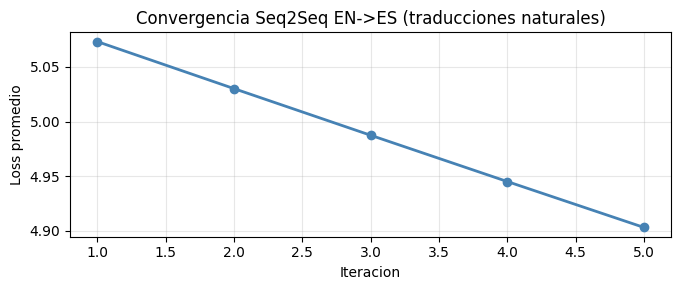

In [22]:
if losses_train:
    plt.figure(figsize=(7,3))
    plt.plot(range(1,6), losses_train, 'o-', color='steelblue', linewidth=2)
    plt.xlabel('Iteracion'); plt.ylabel('Loss promedio')
    plt.title('Convergencia Seq2Seq EN->ES (traducciones naturales)')
    plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig('convergencia_seq2seq.png', dpi=110, bbox_inches='tight')
    plt.show()

---
## Bloque 12: Preguntas de analisis

---

### Pregunta 1 (35 pts)

El corpus tiene tres tipos de pares: traducciones mas cortas en espanol (elision del sujeto: *she sings well* -> *canta bien*), mas largas (perifrasis: *the cat sleeps* -> *el gato esta durmiendo*), y del mismo largo.

a) Durante el entrenamiento con teacher forcing, el decoder para el par (*she sings well*, *canta bien*) corre 2 pasos y para (*the cat sleeps*, *el gato esta durmiendo*) corre 4 pasos. Explique como afecta esa diferencia al gradiente que llega a los pesos del encoder en cada caso. Use la formula del recorrido del gradiente $S + T$ pasos.

b) Durante la inferencia greedy, el decoder debe aprender a generar EOS en el momento correcto. Para un par donde el espanol es mas corto que el ingles, ¿que debe haber aprendido el modelo para detener la generacion antes de que el decoder produzca tantos tokens como el encoder proceso? ¿Que informacion del encoder codifica esa senal de parada?

c) Si ordenara el corpus de entrenamiento de menor a mayor largo de la secuencia de salida (curriculum learning), ¿esperaria que el modelo convergiera mas rapido, mas lento, o igual? Justifique en terminos del gradiente y del proceso de aprendizaje.

**Su respuesta a la Pregunta 1:**

a) En ambos casos el gradiente que actualiza al encoder debe atravesar primero los pasos del decoder y después los pasos del encoder. Usando los largos indicados en la pregunta, para *she sings well* el recorrido es $S+T=2+3=5$ pasos, mientras que para *the cat sleeps* es $S+T=4+3=7$ pasos. El segundo caso aporta gradientes desde más predicciones del decoder, pero las dependencias más lejanas recorren más transformaciones recurrentes y tienen mayor riesgo de atenuarse o crecer. Por eso los pesos del encoder reciben la suma de más contribuciones, aunque algunas pueden llegar más debilitadas. En la implementación, EOS también se predice y añade un paso a ambos recorridos (6 y 8, respectivamente), sin cambiar la comparación.

b) El modelo debe aprender a asignar una probabilidad alta a EOS cuando el prefijo español ya expresa toda la información de la entrada. La detención no depende de que el número de pasos del decoder sea igual al del encoder, sino del estado oculto del decoder, condicionado tanto por el contexto como por las palabras generadas anteriormente. Los estados finales $h_T^{enc}$ y $c_T^{enc}$ resumen el contenido semántico, la estructura y el largo aproximado de la oración; esa información permite que el decoder reconozca que la traducción está completa y genere EOS antes.

c) Esperaría una convergencia inicial más rápida. Las salidas cortas producen recorridos BPTT más cortos, gradientes normalmente más estables y ejemplos sencillos para aprender primero asociaciones frecuentes y la generación de EOS. Esos parámetros sirven como punto de partida para las secuencias largas. Sin embargo, ordenar siempre los datos puede sesgar las últimas actualizaciones de cada época hacia las oraciones largas; por ello convendría aplicar el currículo al inicio y luego mezclar el corpus. El currículo puede acelerar el aprendizaje, pero no garantiza una mejor loss final.

---
### Pregunta 2 (35 pts)

a) En el Bloque 10 evalua el porcentaje de oraciones donde la primera palabra generada es correcta. Explique por que esa metrica es mas informativa que la loss de entrenamiento para evaluar la calidad de un sistema de traduccion, y cuales son sus limitaciones.

b) El Bloque 7 muestra que solo una fraccion de las columnas de `E_enc` tienen gradiente no cero en cada actualizacion. Con 78 pares de entrenamiento y 158 palabras en el vocabulario ingles, estime cuantas palabras del vocabulario podrian nunca recibir gradiente durante 5 iteraciones, y que implicacion tiene eso para la representacion de esas palabras.

c) Si quisiera extender este modelo para traducir del espanol al ingles ademas de del ingles al espanol (un solo modelo bidireccional), describa dos enfoques arquitectonicos distintos y justifique cual de los dos preserva mejor la informacion aprendida en este laboratorio.

**Su respuesta a la Pregunta 2:**

a) La exactitud de la primera palabra se calcula sobre datos de prueba y con generación autónoma, así que comprueba una decisión lingüística real sin teacher forcing. En cambio, una loss de entrenamiento baja solo indica que el modelo asigna mayor probabilidad a los tokens correctos cuando recibe los prefijos verdaderos, y puede ocultar sobreajuste o errores durante la inferencia. La métrica también es limitada: ignora todas las palabras posteriores, el orden y el momento de EOS; penaliza sinónimos válidos y no distingue una traducción casi correcta de una completamente incorrecta. Debe complementarse con la loss de prueba y métricas de secuencia completa.

b) Aunque la pregunta menciona 78 pares de entrenamiento, el split ejecutado contiene 58 pares de entrenamiento y 20 de prueba. El vocabulario inglés posee 158 columnas: 154 palabras del corpus y 4 símbolos especiales. En los 58 pares aparecen 123 palabras distintas, por lo que 31 palabras de contenido no reciben gradiente; además, los cuatro símbolos especiales no se leen directamente en el encoder. Por tanto, hasta 35 columnas de `E_enc` pueden permanecer con su valor inicial. Las cinco iteraciones repiten exactamente el mismo conjunto y no corrigen esa falta de cobertura. Si realmente se entrenara con los 78 pares, las 154 palabras de contenido aparecerían y solo las 4 columnas especiales quedarían sin actualizar. Una palabra sin gradiente conserva una representación aleatoria y el encoder no aprende cómo usarla, perjudicando las oraciones de prueba que la contienen.

c) Un enfoque es usar un único encoder-decoder con vocabulario compartido y un token de dirección, por ejemplo `<2es>` o `<2en>`. Esto comparte casi todos los parámetros y facilita transferencia entre idiomas, pero puede causar interferencia y obliga a adaptar embeddings y la capa de salida. Otro enfoque es construir un solo sistema con dos encoders y dos decoders: encoder inglés con decoder español para EN→ES, y encoder español con decoder inglés para ES→EN, posiblemente compartiendo el espacio de contexto. El segundo preserva mejor lo aprendido aquí porque permite conservar sin cambios el encoder inglés y el decoder español ya entrenados, mientras se agregan los módulos de la dirección inversa. Su costo es usar más parámetros y compartir menos conocimiento.

---
### Pregunta 3 (30 pts)

a) Si convirtiera este seq2seq en un autoencoder para comprimir oraciones en espanol, describa exactamente los tres cambios de codigo necesarios en el Bloque 9. Sea especifico sobre la funcion de perdida, los tokens de entrada y salida del decoder, y los vocabularios.

b) En el seq2seq, el backward fluye desde la perdida hasta `E_enc` a traves de $S + T$ pasos. En un autoencoder sobre el mismo corpus, ¿ese recorrido seria el mismo, mas corto o mas largo? Justifique considerando que las oraciones de entrada y salida son iguales.

c) El vector de contexto $\mathbf{c}$ de dimension 32 debe comprimir toda la informacion de la entrada. Para las oraciones mas largas del corpus (*nosotros nos reunimos cada semana*, 5 palabras), ¿es suficiente esa dimension? ¿Que pasaria con la calidad de la reconstruccion si redujera la dimension a 2?

**Su respuesta a la Pregunta 3:**

a) Se requieren tres cambios. (1) En cada par se ignora la oración inglesa y se usa la misma oración española como entrada y como objetivo; el encoder recibe los tokens españoles sin SOS ni EOS. (2) Para teacher forcing se tokeniza esa oración como `[SOS, w_1, ..., w_n, EOS]`, se usa `[SOS, w_1, ..., w_{n-1}]` como entrada del decoder y `[w_1, ..., w_n, EOS]` como target. (3) Tanto el embedding del encoder como el del decoder y la salida `Wo2` deben usar el vocabulario español (`tgt_V`). `compute_loss` no cambia: sigue siendo entropía cruzada categórica promedio, pero ahora compara cada logit con el siguiente token español de la misma oración.

b) En el autoencoder el recorrido es aproximadamente $T_{ES}+S_{ES}$; como entrada y salida contienen la misma oración, equivale a cerca de dos veces su largo, más el paso de EOS. En el traductor es $T_{EN}+S_{ES}$. Por eso no existe una respuesta única para cada par: el autoencoder es más corto cuando el español es más corto que el inglés, igual cuando ambos largos coinciden y más largo cuando el español es más largo. En este corpus 57 de 78 traducciones españolas son más cortas, 8 tienen el mismo largo y 13 son más largas, así que en promedio el recorrido del autoencoder sería más corto.

c) Para este corpus pequeño y oraciones de hasta cinco palabras, 32 dimensiones probablemente ofrecen capacidad suficiente para almacenar la información necesaria, aunque un vector fijo sigue siendo un cuello de botella y no garantiza una reconstrucción perfecta. Reducirlo a 2 dimensiones forzaría oraciones con contenido y orden diferentes a ocupar representaciones muy cercanas. El decoder perdería detalles sobre palabras, orden y largo, aumentaría la loss y tendería a producir reconstrucciones genéricas, incompletas o un EOS incorrecto.

---
## Bloque 13: Nota automatica sobre la seccion de codigo

In [23]:
_PUNTOS = {
    'b2': ('Bloque 2:  Encoder forward',           18),
    'b4': ('Bloque 4:  Perdida CE categorica',       8),
    'b5': ('Bloque 5:  Backward decoder',           14),
    'b6': ('Bloque 6:  Backward encoder',           10),
    'b7': ('Bloque 7:  dE completa vs diccionario',  5),
    'b8': ('Bloque 8:  Actualizacion de pesos',      2),
    'b9': ('Bloque 9:  Convergencia 5 iteraciones',  3),
}
_TOTAL = 60
print('=' * 62)
print('  NOTA AUTOMATICA - SECCION DE CODIGO')
print('=' * 62)
_obtenido = 0
for key, (nombre, pts_max) in _PUNTOS.items():
    val = _resultados.get(key, False)
    pts = pts_max if val is True else 0
    _obtenido += pts
    print(f'  {"CORRECTO" if val is True else "PENDIENTE":10s} | {nombre:38s} | {pts:2d}/{pts_max} pts')
if isinstance(_resultados.get('b10'), float):
    print(f'  INFO       | B10 primera palabra test: {_resultados["b10"]:.1f}%')
print('-' * 62)
print(f'  Subtotal codigo:   {_obtenido}/{_TOTAL} puntos')
print('  Pendiente manual:')
print('    Bloque 12 preguntas : __/25 pts')
print('    Comentarios codigo  : __/15 pts')
print('-' * 62)
print('  TOTAL FINAL (sobre 100): __/100 pts')
print('=' * 62)

  NOTA AUTOMATICA - SECCION DE CODIGO
  CORRECTO   | Bloque 2:  Encoder forward             | 18/18 pts
  CORRECTO   | Bloque 4:  Perdida CE categorica       |  8/8 pts
  CORRECTO   | Bloque 5:  Backward decoder            | 14/14 pts
  CORRECTO   | Bloque 6:  Backward encoder            | 10/10 pts
  CORRECTO   | Bloque 7:  dE completa vs diccionario  |  5/5 pts
  CORRECTO   | Bloque 8:  Actualizacion de pesos      |  2/2 pts
  CORRECTO   | Bloque 9:  Convergencia 5 iteraciones  |  3/3 pts
  INFO       | B10 primera palabra test: 0.0%
--------------------------------------------------------------
  Subtotal codigo:   60/60 puntos
  Pendiente manual:
    Bloque 12 preguntas : __/25 pts
    Comentarios codigo  : __/15 pts
--------------------------------------------------------------
  TOTAL FINAL (sobre 100): __/100 pts
